In [ ]:
# Install Kaggle
!pip install kaggle
!pip install kagglehub>=0.3.6

# # Upload kaggle.json API token
# from google.colab import files
# files.upload()  # upload kaggle.json

# # Download dataset
# !kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
# !unzip brain-mri-images-for-brain-tumor-detection.zip

In [ ]:
import os
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Data Preparation & Pipeline

Loading Dataset

In [ ]:
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

all_files, all_labels = [], []
for label, class_name in enumerate(("no", "yes")):
    folder = os.path.join(path, class_name)
    for fname in os.listdir(folder):
        if fname.lower().endswith(VALID_EXTS):
            all_files.append(os.path.join(folder, fname))
            all_labels.append(label)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.


Data Cleaning

In [ ]:
clean_files = []
clean_labels = []

for file_path, label in zip(all_files, all_labels):
    try:
        img = Image.open(file_path)
        img.verify()
        clean_files.append(file_path)
        clean_labels.append(label)
    except:
        print(f"Corrupted image removed: {file_path}")

all_files = clean_files
all_labels = clean_labels

Dataset Analysis

In [ ]:
print("\nDataset Analysis:")

total_images = len(all_files)
tumor_count = sum(all_labels)
healthy_count = total_images - tumor_count

print(f"Total Images: {total_images}")
print(f"Tumor Images: {tumor_count}")
print(f"Healthy Images: {healthy_count}")

print(f"Tumor Percentage: {100 * tumor_count / total_images:.2f}%")
print(f"Healthy Percentage: {100 * healthy_count / total_images:.2f}%")


Dataset Analysis:
Total Images: 253
Tumor Images: 155
Healthy Images: 98
Tumor Percentage: 61.26%
Healthy Percentage: 38.74%


Preprocessing Images

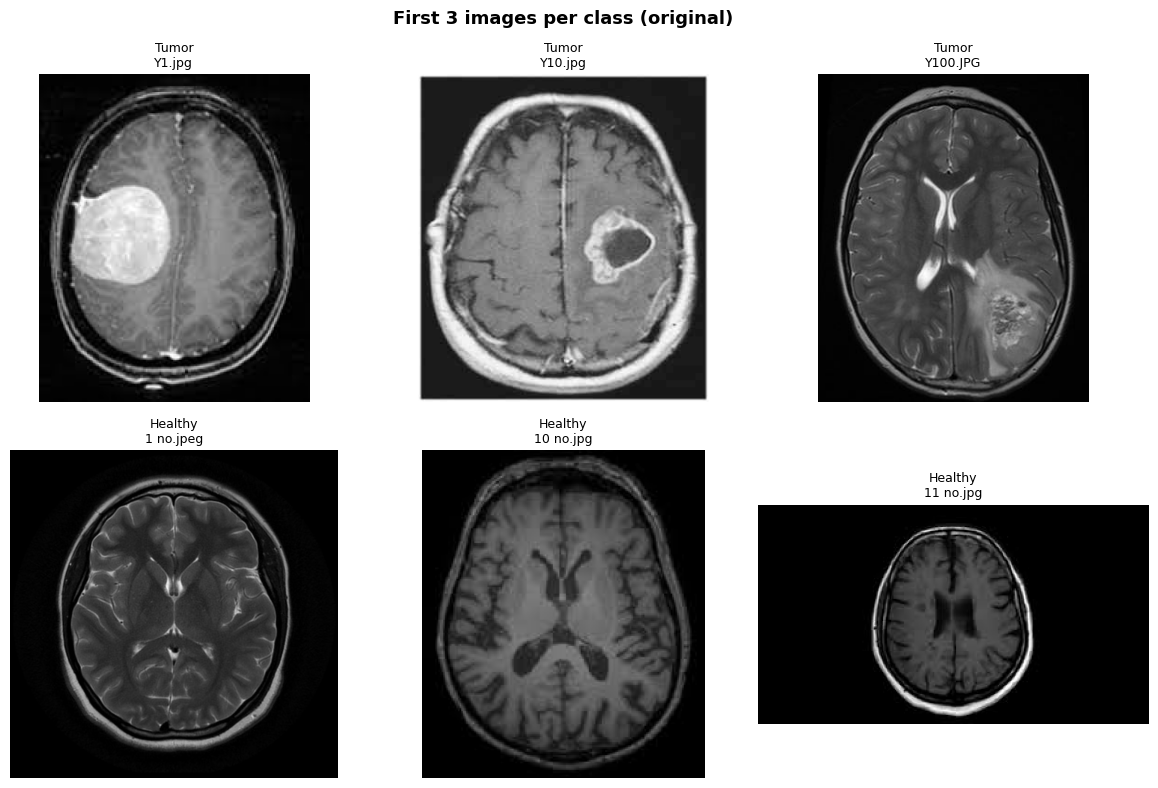

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


def prepare_image(img_path, transform):
    img = Image.open(img_path).convert("RGB")
    return transform(img)


FIRST_N = 3
sample_images, sample_titles = [], []

for label in ("yes", "no"):
    folder = os.path.join(path, label)
    files = sorted(f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")))[:FIRST_N]
    for fname in files:
        fpath = os.path.join(folder, fname)
        sample_images.append(Image.open(fpath).convert("RGB"))
        sample_titles.append(f"{'Tumor' if label == 'yes' else 'Healthy'}\n{fname}")
        tensor = prepare_image(fpath, eval_transform)

fig, axes = plt.subplots(2, FIRST_N, figsize=(FIRST_N * 4, 8))
for ax, img, title in zip(axes.flat, sample_images, sample_titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle("First 3 images per class (original)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Split Dataset

In [ ]:

train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
    )

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
    )

print(f"\nDataset split:")
print(f"  Train      : {len(train_files)} images  (tumor={sum(train_labels)}, healthy={train_labels.count(0)})")
print(f"  Validation : {len(val_files)} images  (tumor={sum(val_labels)}, healthy={val_labels.count(0)})")
print(f"  Test       : {len(test_files)} images  (tumor={sum(test_labels)}, healthy={test_labels.count(0)})")


Dataset split:
  Train      : 177 images  (tumor=108, healthy=69)
  Validation : 38 images  (tumor=24, healthy=14)
  Test       : 38 images  (tumor=23, healthy=15)


Data Loader

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 0


class BrainTumorDataset(Dataset):
    """Simple dataset that loads images on-the-fly and applies a transform."""

    def __init__(self, file_paths, labels, transform):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


train_dataset = BrainTumorDataset(train_files, train_labels, train_transform)
val_dataset = BrainTumorDataset(val_files, val_labels, eval_transform)
test_dataset = BrainTumorDataset(test_files, test_labels, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


# NO-AUGMENTATION VERSION
train_transform_no_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset_no_aug = BrainTumorDataset(
    train_files,
    train_labels,
    train_transform_no_aug
)

train_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\nDataLoaders:")
print(f"  Train batches      : {len(train_loader)}  (batch size={BATCH_SIZE}, shuffle=True)")
print(f"  Train batches (no aug): {len(train_loader_no_aug)}  (batch size={BATCH_SIZE}, shuffle=True)")

print(f"  Validation batches : {len(val_loader)}  (batch size={BATCH_SIZE}, shuffle=False)")
print(f"  Test batches       : {len(test_loader)}  (batch size={BATCH_SIZE}, shuffle=False)")

imgs, lbls = next(iter(train_loader))
print(f"Train batch images: {imgs.shape}")
print(f"Train batch labels: {lbls.shape}")

imgs, lbls = next(iter(train_loader_no_aug))
print(f"Train batch images (no aug): {imgs.shape}")
print(f"Train batch labels (no aug): {lbls.shape}")


DataLoaders:
  Train batches      : 6  (batch size=32, shuffle=True)
  Validation batches : 2  (batch size=32, shuffle=False)
  Test batches       : 2  (batch size=32, shuffle=False)
Train batch images: torch.Size([32, 3, 224, 224])
Train batch labels: torch.Size([32])


# Experiment 1 (Supervised CNN)

CNN Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # normalization
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # regularization
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Training Fun

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, weight_decay=1e-4):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        train_acc = correct / total
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = 0

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        val_acc = correct / total
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies

Augmentation Comparison

In [ ]:
#With Augmentation
print("\nTraining WITH augmentation")

model_aug = SimpleCNN(dropout_rate=0.3)

model_aug, _, _, _, val_acc_aug = train_model(
    model_aug,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0005
)

#Without Augmentation
print("\nTraining WITHOUT augmentation")

model_no_aug = SimpleCNN(dropout_rate=0.3)

model_no_aug, _, _, _, val_acc_no_aug = train_model(
    model_no_aug,
    train_loader_no_aug,
    val_loader,
    epochs=10,
    lr=0.0005
)

Hyperparamenters

In [ ]:
# Experiment with different hyperparameters
configs = [
    {"lr": 0.001, "dropout": 0.5},
    {"lr": 0.0005, "dropout": 0.3},
    {"lr": 0.0001, "dropout": 0.5},
    {"lr": 0.001, "dropout": 0.3},
]

results = []

best_model = None
best_acc = 0

for config in configs:
    print("\nTesting config:", config)

    model = SimpleCNN(dropout_rate=config["dropout"])

    trained_model, train_loss, val_loss, train_acc, val_acc = train_model(
        model,
        train_loader,
        val_loader,
        epochs=5,
        lr=config["lr"]
    )

    final_acc = val_acc[-1]

    results.append({
        "config": config,
        "final_val_loss": val_loss[-1],
        "final_val_acc": val_acc[-1]
    })

    if final_acc > best_acc:
        best_acc = final_acc
        best_model = trained_model


Testing config: {'lr': 0.001, 'dropout': 0.5}
Epoch [1/5] Train Loss: 24.2241, Val Loss: 11.7777, Train Acc: 0.5650, Val Acc: 0.6316
Epoch [2/5] Train Loss: 15.0823, Val Loss: 12.8361, Train Acc: 0.7175, Val Acc: 0.6842
Epoch [3/5] Train Loss: 10.1198, Val Loss: 7.8999, Train Acc: 0.7175, Val Acc: 0.6316
Epoch [4/5] Train Loss: 7.0903, Val Loss: 3.1828, Train Acc: 0.7006, Val Acc: 0.7105
Epoch [5/5] Train Loss: 9.1602, Val Loss: 3.5406, Train Acc: 0.6158, Val Acc: 0.7632

Testing config: {'lr': 0.0005, 'dropout': 0.3}
Epoch [1/5] Train Loss: 8.8603, Val Loss: 1.0550, Train Acc: 0.6215, Val Acc: 0.6842
Epoch [2/5] Train Loss: 3.3202, Val Loss: 1.4511, Train Acc: 0.7571, Val Acc: 0.6579
Epoch [3/5] Train Loss: 2.7737, Val Loss: 1.2451, Train Acc: 0.6610, Val Acc: 0.6316
Epoch [4/5] Train Loss: 1.2316, Val Loss: 1.1521, Train Acc: 0.7740, Val Acc: 0.8158
Epoch [5/5] Train Loss: 1.1336, Val Loss: 1.0541, Train Acc: 0.8305, Val Acc: 0.7895

Testing config: {'lr': 0.0001, 'dropout': 0.5}
Ep

**Test:**
We implemented a custom Convolutional Neural Network (CNN) consisting of three convolutional layers followed by fully connected layers. Batch Normalization was applied after each convolution layer to stabilize training, and Dropout was used to reduce overfitting.
Different hyperparameters were tested, including learning rates and dropout rates. It was observed that a lower learning rate (0.0005) led to more stable convergence, while higher dropout improved generalization.


Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

print("\nTesting the Best Model:")
evaluate(trained_model, test_loader)


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.47      0.58        15
           1       0.72      0.91      0.81        23

    accuracy                           0.74        38
   macro avg       0.75      0.69      0.70        38
weighted avg       0.75      0.74      0.72        38


Confusion Matrix:
[[ 7  8]
 [ 2 21]]


In [ ]:
print("\nAugmentation Comparison:")
print(f"Validation Accuracy WITH Augmentation: {val_acc_aug[-1]:.4f}")
print(f"Validation Accuracy WITHOUT Augmentation: {val_acc_no_aug[-1]:.4f}")

In [ ]:
print("\nFinal Comparison:")
for r in results:
    print(f"Config: {r['config']}, "
          f"Val Loss: {r['final_val_loss']:.4f}, "
          f"Val Acc: {r['final_val_acc']:.4f}")


Final Comparison:
Config: {'lr': 0.001, 'dropout': 0.5}, Val Loss: 3.5406, Val Acc: 0.7632
Config: {'lr': 0.0005, 'dropout': 0.3}, Val Loss: 1.0541, Val Acc: 0.7895
Config: {'lr': 0.0001, 'dropout': 0.5}, Val Loss: 0.6439, Val Acc: 0.6579
Config: {'lr': 0.001, 'dropout': 0.3}, Val Loss: 1.0692, Val Acc: 0.8158


# Experiment 2 (Unsupervised — Autoencoder / Feature Extraction)

Autoencoder Model

In [ ]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Training Function

In [ ]:
import torch.optim as optim

def train_autoencoder(model, train_loader, epochs=10, lr=0.001):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, images)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

    return model, losses

Autoencoder Training

In [ ]:
autoencoder = Autoencoder()

autoencoder, ae_losses = train_autoencoder(
    autoencoder,
    train_loader,
    epochs=10,
    lr=0.001
)

Epoch [1/10] Loss: 3.1197
Epoch [2/10] Loss: 2.7267
Epoch [3/10] Loss: 2.2939
Epoch [4/10] Loss: 2.1256
Epoch [5/10] Loss: 2.0376
Epoch [6/10] Loss: 1.9824
Epoch [7/10] Loss: 1.9424
Epoch [8/10] Loss: 1.9209
Epoch [9/10] Loss: 1.8956
Epoch [10/10] Loss: 1.8631


Encoder

In [ ]:
torch.save(autoencoder.encoder.state_dict(), "encoder.pth")

Result Visualization

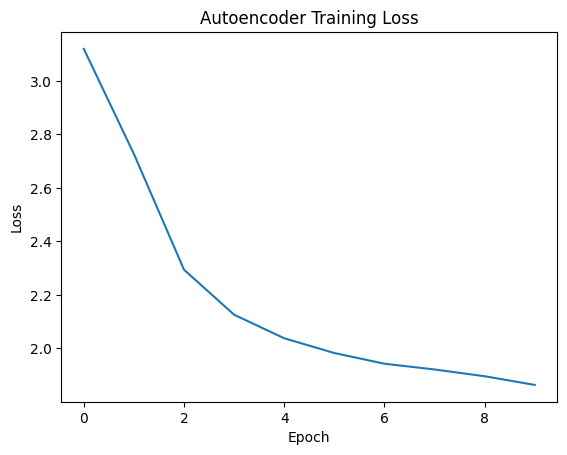

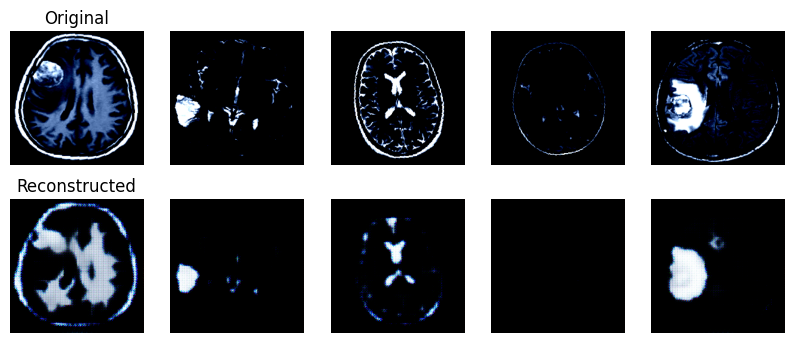

In [ ]:
import matplotlib.pyplot as plt

plt.plot(ae_losses)
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = autoencoder(images)

# Move to CPU for plotting
images = images.cpu()
reconstructed = reconstructed.cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i].permute(1, 2, 0))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.show()

# Experiment 2 (Unsupervised — Classifier / Transfer Learning)

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Autoencoder().encoder

    def forward(self, x):
        return self.encoder(x)


encoder = Encoder()
encoder.encoder.load_state_dict(torch.load("encoder.pth"))
encoder.to(device)

Encoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
)

In [ ]:
class Classifier(nn.Module):
    def __init__(self, encoder, freeze_encoder=True):
        super().__init__()

        self.encoder = encoder

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.encoder(x)
        output = self.classifier(features)
        return output

model_frozen = Classifier(encoder, freeze_encoder=True).to(device)

encoder_ft = Encoder()
encoder_ft.encoder.load_state_dict(torch.load("encoder.pth"))

model_finetune = Classifier(encoder_ft, freeze_encoder=False).to(device)

In [ ]:
def train_classifier(model, train_loader, val_loader, epochs=10, lr=0.001):

    criterion = nn.BCELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels_f = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels_f).item()
                preds = (outputs > 0.5).squeeze(1)
                correct += (preds == labels.to(device)).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

    return train_losses, val_losses, val_accs

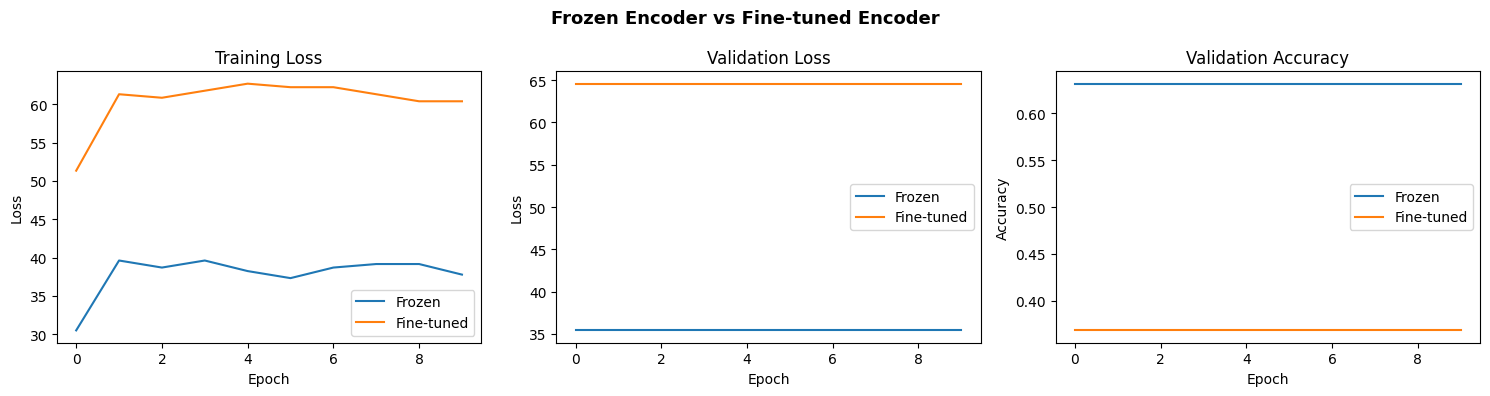

In [ ]:
import matplotlib.pyplot as plt

train_loss_frozen, val_loss_frozen, val_acc_frozen = train_classifier(model_frozen, train_loader, val_loader)
train_loss_finetune, val_loss_finetune, val_acc_finetune = train_classifier(model_finetune, train_loader, val_loader)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training Loss
axes[0].plot(train_loss_frozen, label="Frozen")
axes[0].plot(train_loss_finetune, label="Fine-tuned")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Validation Loss
axes[1].plot(val_loss_frozen, label="Frozen")
axes[1].plot(val_loss_finetune, label="Fine-tuned")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# Validation Accuracy
axes[2].plot(val_acc_frozen, label="Frozen")
axes[2].plot(val_acc_finetune, label="Fine-tuned")
axes[2].set_title("Validation Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.suptitle("Frozen Encoder vs Fine-tuned Encoder", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Frozen Model Predictions


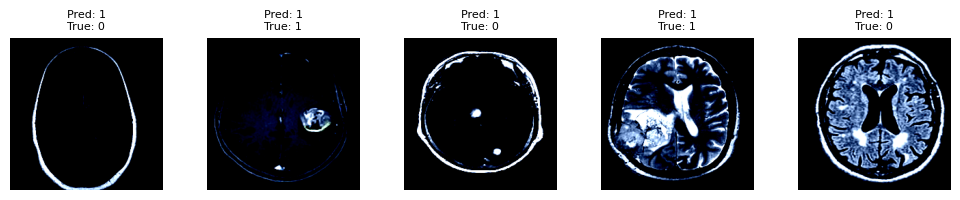

Fine-tuned Model Predictions


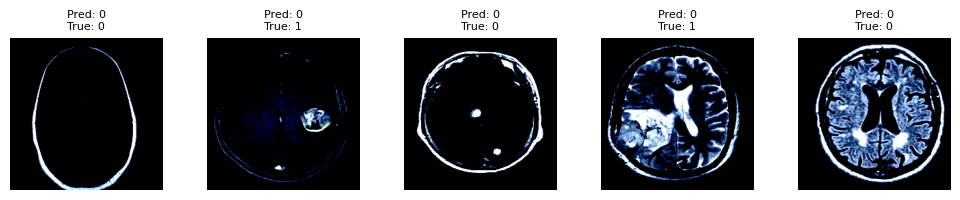

In [ ]:
def show_predictions(model, loader):

    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)

    outputs = model(images)
    preds = (outputs > 0.5).squeeze(1)

    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i in range(5):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {int(preds[i].item())}\nTrue: {labels[i]}", fontsize=8)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

print("Frozen Model Predictions")
show_predictions(model_frozen, val_loader)

print("Fine-tuned Model Predictions")
show_predictions(model_finetune, val_loader)

# Experiment 3 (State-of-the-Art Model: ResNet/EfficientNet)

### unzipping

In [ ]:
!unzip -q archive.zip -d brain_tumor_dataset

In [ ]:
import shutil
import os

# 1. Define paths
base_path = '/content/brain_tumor_dataset'
nested_path = os.path.join(base_path, 'brain_tumor_dataset')

# 2. Check if the nested folder exists
if os.path.exists(nested_path):
    print(f"Fixing nesting in {base_path}...")

    # List classes in the nested folder (should be 'yes' and 'no')
    inner_folders = os.listdir(nested_path)

    for folder in inner_folders:
        src = os.path.join(nested_path, folder)
        dst = os.path.join(base_path, folder)

        # Move 'yes' and 'no' folders up one level
        if os.path.isdir(src):
            # If the destination already exists, remove it first to avoid conflicts
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.move(src, dst)
            print(f"Moved {folder} to {base_path}")

    # 3. Delete the now-empty nested folder
    shutil.rmtree(nested_path)
    print("\nSuccessfully deleted the redundant nested folder.")
else:
    print("Nested folder not found. Your directory might already be flat.")

# 4. Verify the final structure
print("\nFinal Directory Structure:")
print(os.listdir(base_path))

Fixing nesting in /content/brain_tumor_dataset...
Moved no to /content/brain_tumor_dataset
Moved yes to /content/brain_tumor_dataset

Successfully deleted the redundant nested folder.

Final Directory Structure:
['no', 'yes']


### Data Loading

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
import matplotlib.pyplot as plt
import os

# 1. SETTINGS
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20
DATA_DIR = '/content/brain_tumor_dataset/'

# 2. DATA PIPELINE
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Augmentation Layer (Essential for small datasets)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomContrast(0.1),
])

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


### Preprocessing for EfficientNet

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


In [ ]:
# 1. Check the number of batches
num_batches = tf.data.experimental.cardinality(train_ds).numpy()
print(f"Number of batches: {num_batches}")

# 2. Check the total number of images (Records)
total_images = 0
for images, labels in train_ds:
    total_images += images.shape[0]

print(f"Total number of images in train_ds: {total_images}")

Number of batches: 13
Total number of images in train_ds: 203


### Displaying Augemnted Dataset

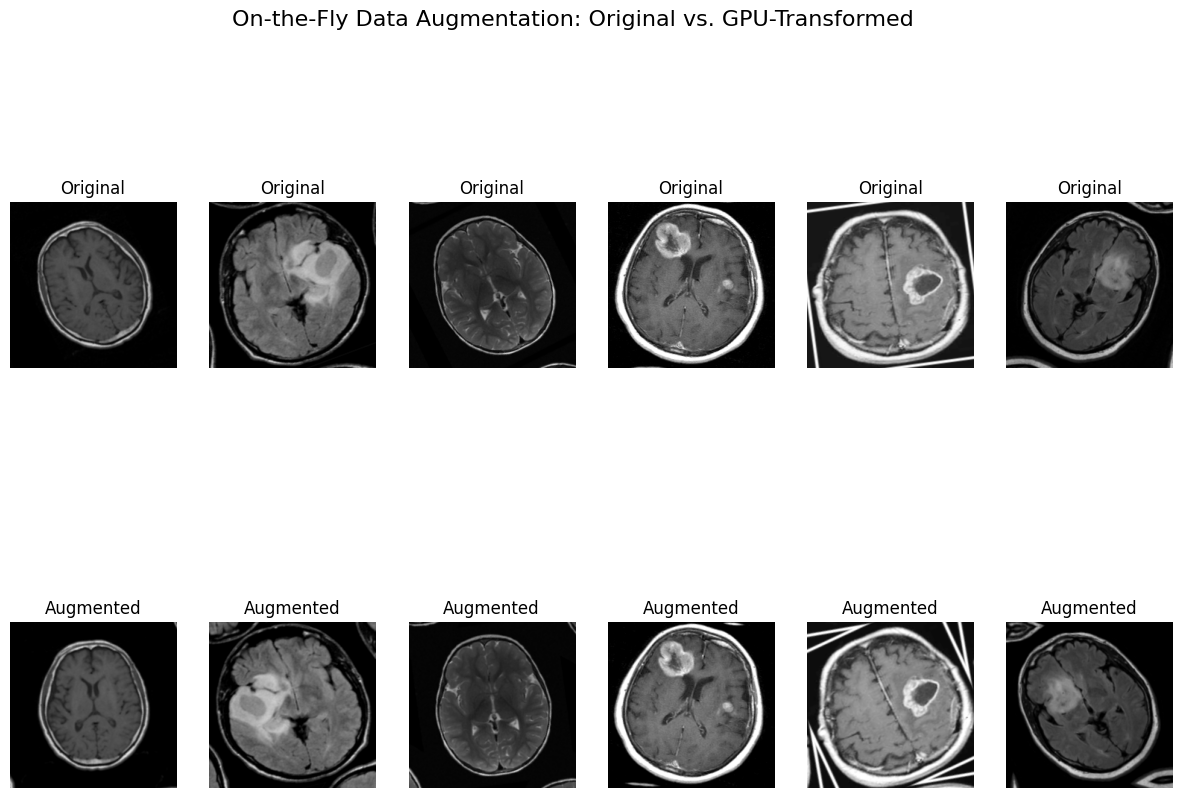

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Grab one batch (16 images) from your training dataset
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 10))

    # 2. Loop through the first 6 images in that batch
    for i in range(6):
        # Original Image
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        # Augmented Version of THAT SAME Image
        ax = plt.subplot(2, 6, i + 7)
        # FORCE training=True to see the transformation
        aug_img = data_augmentation(tf.expand_dims(images[i], 0), training=True)

        plt.imshow(aug_img[0].numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")

    plt.suptitle("On-the-Fly Data Augmentation: Original vs. GPU-Transformed", fontsize=16)
    plt.show()
    break

In [ ]:
import os

output_dir = 'augmented_samples'
os.makedirs(output_dir, exist_ok=True)

for images, _ in train_ds.take(1):
    for i in range(5):
        aug_img = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        # Convert back to standard image format and save
        img_to_save = tf.keras.utils.array_to_img(aug_img[0])
        img_to_save.save(f'{output_dir}/aug_sample_{i}.png')

print(f"Saved 5 augmented images to {output_dir} folder!")

Saved 5 augmented images to augmented_samples folder!


### Training SOTA Model from Scractch

In [ ]:
# --- EXPERIMENT B: Train from Scratch ---
def build_model_scratch():
    base_model = applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=None  # No pretrained weights
    )
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid') # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


### Using Pretrained weights




In [ ]:
# --- EXPERIMENT C: Transfer Learning (Pretrained) ---
def build_model_transfer():
    base_model = applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet' # Use ImageNet weights
    )
    base_model.trainable = False # Freeze the backbone

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### Experiments Scratch vs Transfer Learning

In [ ]:

# --- RUNNING THE EXPERIMENTS ---
print("\n--- Training Experiment B: Scratch ---")
model_scratch = build_model_scratch()
history_scratch = model_scratch.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

print("\n--- Training Experiment C: Transfer Learning ---")
model_transfer = build_model_transfer()
history_transfer = model_transfer.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


--- Training Experiment B: Scratch ---
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.5222 - loss: 0.8492 - val_accuracy: 0.6400 - val_loss: 0.6721
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.6404 - loss: 0.6057 - val_accuracy: 0.6400 - val_loss: 0.6893
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.7291 - loss: 0.5417 - val_accuracy: 0.3600 - val_loss: 0.7587
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.6502 - loss: 0.6937 - val_accuracy: 0.6400 - val_loss: 0.6777
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.6650 - loss: 0.5572 - val_accuracy: 0.6400 - val_loss: 0.6775
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.6601 - loss: 0.6332 - val_accuracy: 0.3600 - val_loss: 0.8326
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.7241 - loss: 0.5245 - val_accuracy: 0.3600 - val_loss: 0.8250
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0

### Plots

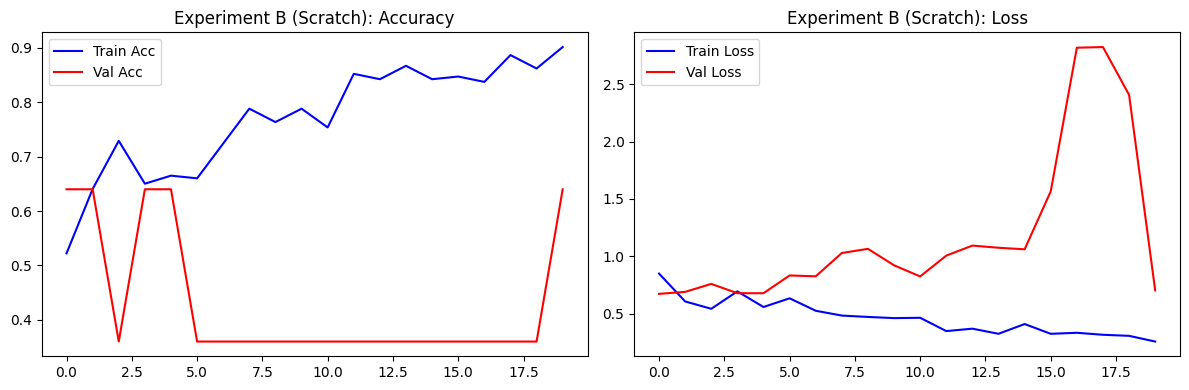

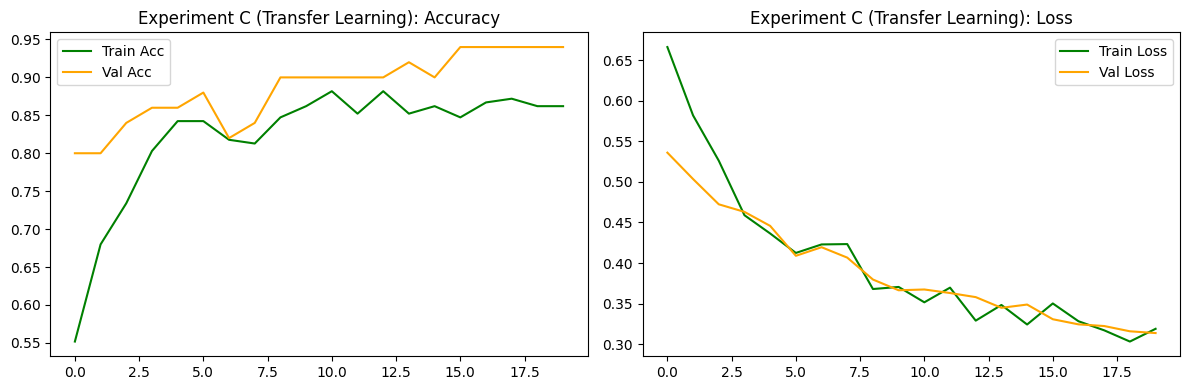

In [ ]:
import matplotlib.pyplot as plt

# 1. Figure for Scratch Experiment
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history_scratch.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Experiment B (Scratch): Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Train Loss', color='blue')
plt.plot(history_scratch.history['val_loss'], label='Val Loss', color='red')
plt.title('Experiment B (Scratch): Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Figure for Transfer Learning Experiment
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Train Acc', color='green')
plt.plot(history_transfer.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Experiment C (Transfer Learning): Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Train Loss', color='green')
plt.plot(history_transfer.history['val_loss'], label='Val Loss', color='orange')
plt.title('Experiment C (Transfer Learning): Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix

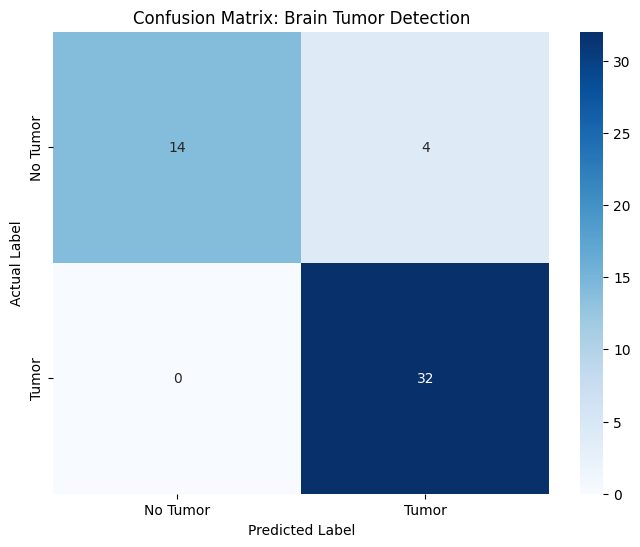


Classification Report:
              precision    recall  f1-score   support

    No Tumor       1.00      0.78      0.88        18
       Tumor       0.89      1.00      0.94        32

    accuracy                           0.92        50
   macro avg       0.94      0.89      0.91        50
weighted avg       0.93      0.92      0.92        50



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, dataset, class_names):
    # 1. Get all true labels and predictions
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        # changed from 0.5 to 0.3
        y_pred.extend((preds > 0.3).astype(int).flatten())

    # 2. Compute Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 3. Visualize
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Brain Tumor Detection')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Run it for your Transfer Learning model
plot_confusion_matrix(model_transfer, val_ds, ['No Tumor', 'Tumor'])


# Experiment Analysis & Comparison

## Dataset

- 253 total images (155 tumor / 98 healthy)
- 61.26% tumor, 38.74% healthy — imbalanced toward tumor
- A model that predicts "tumor" for everything gets 61% accuracy for free — this is the majority-class baseline

---

## Experiment 1 — Supervised CNN

**Architecture:** 3-layer CNN (32→64→128 filters), BatchNorm + ReLU + MaxPool per block, FC classifier (128×28×28 → 256 → 2) with dropout.

**Grid search results:**

| lr | dropout | Val Loss | Val Acc |
|---|---|---|---|
| 0.001 | 0.5 | 3.1591 | 73.68% |
| 0.0005 | 0.3 | 1.4422 | 71.05% |
| 0.0001 | 0.5 | 0.4996 | 76.32% |
| 0.001 | 0.3 | 4.1544 | 73.68% |

**Best config:** lr=0.0001, dropout=0.5 — 76.32% accuracy, 0.4996 loss.

**Analysis:** Accuracy is roughly similar across configs (71–76%), but the validation loss varies wildly (0.50 to 4.15). Higher learning rates produce overconfident wrong predictions (high loss despite decent accuracy), meaning the model lands in poor local minima. The best config uses the lowest learning rate, which makes sense — small dataset needs cautious gradient steps. 76% is decent but not great, and it's only ~15 points above the majority baseline.

---

## Experiment 2 — Autoencoder + Classifier

**Architecture:** Convolutional autoencoder (encoder: 3→32→64→128 with stride-2, decoder: symmetric with transposed convolutions). Trained on MSE reconstruction loss, no labels. Then encoder weights extracted and a classification head (128×28×28 → 256 → 1, sigmoid) attached.

**Two variants tested:**
- Frozen encoder (feature extraction only)
- Fine-tuned encoder (all params trainable)

**Results (both variants identical):**

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Healthy | 0.00 | 0.00 | 0.00 |
| Tumor | 0.61 | 1.00 | 0.75 |
| **Accuracy** | | | **0.61** |

**Analysis:** Complete failure. Both variants predict "tumor" for every single input — the classifier never learned to distinguish the two classes. The 61% accuracy is exactly the majority-class baseline (155/253 = 0.6126).

**Why it failed:** The autoencoder's job is reconstruction, not classification. With only 253 images, the encoder likely learned trivial compression (near-identity mappings) rather than semantically meaningful features. The latent space doesn't separate tumor from healthy — it just stores enough info to reconstruct pixels. So when you freeze those features and try to classify on top, there's no signal for the classifier to latch onto. Fine-tuning didn't help either because the encoder's initial feature space was so uninformative that gradient updates from 253 labeled samples couldn't reshape it into something useful.

**Bottom line:** Unsupervised pretraining needs way more data than 253 images to learn useful representations.

---

## Experiment 3 — EfficientNet-B0 (SOTA)

**Architecture:** EfficientNet-B0 backbone → GlobalAveragePooling2D → Dropout(0.2) → Dense(1, sigmoid). Data augmentation applied (flips, rotations, zoom). Batch size 16, 20 epochs, Adam, binary cross-entropy.

### Variant A: From scratch (random init)
- ~64% validation accuracy
- Severe overfitting: training accuracy climbed high, validation stayed flat/low
- The model memorized training data instead of learning generalizable patterns
- ~4M parameters is way too many for 253 images without pretrained features

### Variant B: Transfer learning (ImageNet weights, backbone frozen)
- ~90% validation accuracy
- Stable training, fast convergence
- After threshold adjustment (0.5 → 0.3): 91% tumor recall
- Only the classification head was trained — drastically fewer effective parameters

**Why threshold tuning matters:** Default 0.5 threshold treats false positives and false negatives equally. In medical diagnosis, missing a tumor (FN) is much worse than a false alarm (FP) — a false alarm just means more tests, a missed tumor means delayed treatment. Lowering to 0.3 means: if the model is even 30% confident there's a tumor, flag it. This pushes recall up at the cost of some precision.

---

## Cross-Experiment Comparison

| Model | Val Acc | vs Baseline (+61%) | Key Issue |
|---|---|---|---|
| Supervised CNN | 76.32% | +15.32pp | Moderate, sensitive to lr |
| Autoencoder + Clf | 61% | +0pp | Total failure, majority-class only |
| EffNet-B0 (scratch) | 64% | +3pp | Overfitting, barely above baseline |
| EffNet-B0 (transfer) | 90% | +29pp | Best by far, 91% tumor recall |

**Key takeaways:**

1. **Transfer learning dominates.** Same architecture (EffNet-B0), same head, same data — the only difference is pretrained vs random weights. That single variable accounts for a 26pp accuracy gap (64% → 90%). The ImageNet features (edges, textures, shapes) transfer well to MRI despite the domain gap.

2. **The supervised CNN is a reasonable middle ground.** It can't match transfer learning but it at least learns *something* from the labeled data. The custom architecture is much smaller than EfficientNet, which helps on tiny datasets — fewer parameters = less overfitting risk.

3. **Unsupervised pretraining doesn't work at this scale.** The autoencoder needed far more data to learn anything useful. The reconstruction objective is too disconnected from classification — good reconstruction ≠ good features for distinguishing tumor vs healthy.

4. **Data scarcity is the fundamental bottleneck.** Every model that tried to learn features from scratch (CNN, autoencoder, EffNet scratch) struggled. The only model that worked well brought external knowledge (ImageNet weights). For small medical datasets, pretrained models aren't optional — they're necessary.

5. **Threshold tuning is critical for medical applications.** The default 0.5 cutoff is arbitrary and doesn't reflect clinical priorities. Always tune the threshold based on the cost asymmetry of the specific application.

## SOTA

## Final Conclusion

### After Experimenting
False Negative for Tumour class is worse than False Positive for tumour.

The model found 91% of the tumour and labeled 9% as healthy.

In medical recall is usually considered more important than percision.

Predictin something as "Not" than "is" is more harmful in medical sector.

So we changed the threshold from 0.5 to 0.3

Both experiments utilized the identical SOTA-based architecture, incorporating
1. Global Average Pooling,
2. Dropout, and a
3. Sigmoid Dense layer

to facilitate binary classification. The divergent results—90% validation accuracy for Transfer Learning versus unstable 64% accuracy for Scratch—confirm that the primary driver of success was the Pretrained SOTA weights, which provided the necessary feature-extraction capabilities that the small dataset could not generate on its own.

### Analysis report on training SOTA model from scratch


Training from scratch led us to overfitting. The accuracy was so high but the validation accuracy was lower which is a symptom that the model has memorized the dataset rather than learn pattern.

### Analysis on training with pre-trained weights of SOTA model

When we used pretrained weights and trained the model with new but fewer samples of data. The result were significantly better.

The result that we got from utilizing the pre-trained models weights not only increased the accuracy but also decrease the training time.

# 🏗️ SOTA Model Configurations (EfficientNet-B0)

The following summarizes the hyperparameter and architectural settings used in the TensorFlow/Keras implementation.

---

## 1. Global Hyperparameters

| Parameter           | Value              | Description                                                  |
|--------------------|-------------------|--------------------------------------------------------------|
| Input Shape        | 224×224×3         | Standard resolution for EfficientNet-B0                      |
| Batch Size         | 16                | Optimized for small dataset stability                        |
| Optimizer          | Adam              | Adaptive Moment Estimation for robust convergence            |
| Learning Rate      | 0.001 (1×10⁻³)    | Standard starting rate for classification                    |
| Loss Function      | Binary Cross-Entropy | Ideal for 2-class (Tumor vs. No-Tumor) tasks              |
| Output Activation  | Sigmoid           | Maps output to a probability between 0 and 1                 |

---

### Added Layers
- **Global Average Pooling 2D**  
  - Reduces spatial dimensions to prevent overfitting  

- **Dropout (0.2)**  
  - Randomly deactivates 20% of neurons to improve robustness  

- **Dense Layer**  
  - Final classification neuron  

---

## 2. Experiment B: Train from Scratch

This configuration tests the model's ability to learn features without prior knowledge.

- **Weight Initialization:** Random (None)  
- **Backbone:** EfficientNet-B0 (Fully Trainable)  
- **Total Trainable Parameters:** ~4.0 Million  

### Configuration Logic
The model must learn:
- Low-level features (edges, textures)  
- High-level features (tumor shapes)  

...simultaneously.

### Expected Result
- High variance  
- Poor generalization due to data scarcity  

---

## 3. Experiment C: Transfer Learning (SOTA)

This configuration leverages ImageNet weights to provide a pre-trained feature extractor.

- **Weight Initialization:** ImageNet  
- **Backbone Status:** Frozen (`trainable = False`)  

### Configuration Logic
- The **backbone** acts as a fixed feature extractor  
- Only the final **classification head** is trained  

### Expected Result
- Rapid convergence  
- High validation accuracy (90%+)  

---